In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

train_path = "/content/drive/MyDrive/lab/Fashion dataset-20260421T091610Z-3-001/Fashion dataset/fashion-mnist_train.csv"
test_path = "/content/drive/MyDrive/lab/Fashion dataset-20260421T091610Z-3-001/Fashion dataset/fashion-mnist_test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(train_df.shape)

(60000, 785)


In [11]:
class FashionDataset(Dataset):
    def __init__(self, df):
        self.labels = df.iloc[:, 0].values
        self.images = df.iloc[:, 1:].values / 255.0  # normalize

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = torch.tensor(self.images[idx], dtype=torch.float32)
        img = img.view(1, 28, 28)  # reshape
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label

In [12]:
train_dataset = FashionDataset(train_df)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

In [13]:
def add_noise(x):
    noise = torch.randn_like(x) * 0.5
    return torch.clamp(x + noise, 0., 1.)

In [14]:
import torch.nn as nn

class DAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 64)
        )

        self.decoder = nn.Sequential(
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x.view(-1, 1, 28, 28)

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

for epoch in range(20):
    for img, _ in train_loader:
        img = img.to(device)
        noisy = add_noise(img).to(device)

        output = model(noisy)
        loss = criterion(output, img)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.0240
Epoch 2, Loss: 0.0212
Epoch 3, Loss: 0.0191
Epoch 4, Loss: 0.0192
Epoch 5, Loss: 0.0183
Epoch 6, Loss: 0.0177
Epoch 7, Loss: 0.0155
Epoch 8, Loss: 0.0175
Epoch 9, Loss: 0.0148
Epoch 10, Loss: 0.0146
Epoch 11, Loss: 0.0171
Epoch 12, Loss: 0.0154
Epoch 13, Loss: 0.0159
Epoch 14, Loss: 0.0154
Epoch 15, Loss: 0.0138
Epoch 16, Loss: 0.0150
Epoch 17, Loss: 0.0148
Epoch 18, Loss: 0.0155
Epoch 19, Loss: 0.0144
Epoch 20, Loss: 0.0150


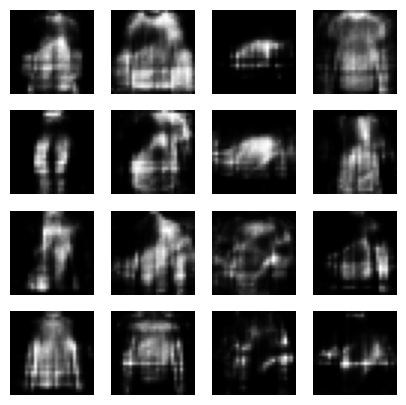

In [18]:
import matplotlib.pyplot as plt

with torch.no_grad():
    z = torch.randn(16, 64).to(device)
    samples = model.decoder(z).cpu()

plt.figure(figsize=(5,5))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(samples[i].view(28,28), cmap='gray')
    plt.axis('off')

plt.show()